In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
import os

#Fonctions d'erreur à fitter#



In [68]:
def erreur(x,Imax,x0,w):
    return (Imax/2)*(1-erf(np.sqrt(2)*(x-x0)/w))

In [69]:
donnees = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS')

distance = [float(i.replace('cm','').replace('_','.')) for i in donnees]

elDic = dict(zip(distance,donnees)) #permet de trier les valeurs selon la distance
laDica = dict(sorted(elDic.items())) #me creer un dictionnaire qui est ordonné selon la distance
for i in laDica:
    print(laDica[i])
    spectre = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS\\{laDica[i]}')
    #plt.scatter(spectre[1:,0],spectre[1:,1])
    #plt.show()

16cm
17cm
18cm
19cm
20cm
21cm
22cm
23cm
24cm
25cm
26cm
27cm
28cm
29cm
30cm
31cm
46cm
61cm
76cm
91cm
106cm
121cm
136cm
142cm


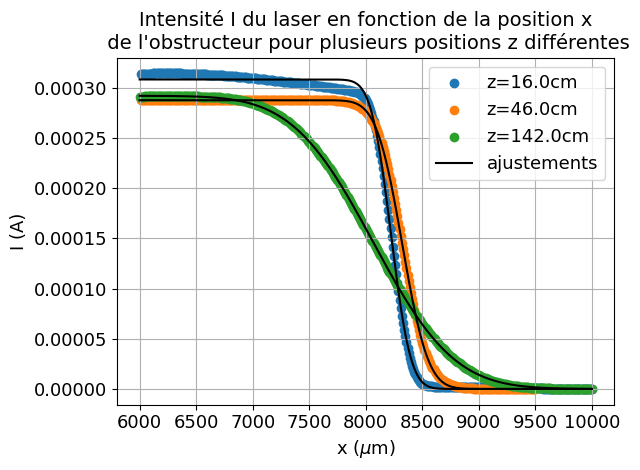

In [240]:
ws = np.zeros(24)
dws = np.zeros(24)
plt.figure(1)
for k,i in enumerate(laDica):
    spectre = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS\\{laDica[i]}')
    x = spectre[1:,0]
    y = spectre[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws[k]=popt[2]
    dws[k] = np.sqrt(pcov[2,2])
    
    
    ###################################################### Permet de voir tous les courbes directement une après l'autre pour vérifier qu'elles sont bonnes ###############################################################
    #print(np.sqrt(pcov[2,2]),popt[2])
    #print(laDica[i])
    #X = np.arange(min(x),max(x))
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt),color='black')
    #plt.show()
    ###############################################################################################################################################
    
    ########## Affichage de trois courbes spécifiques pour orbserver erf selon z ####################

    if i == 16.0 or i == 46 or i ==142:
        X = np.arange(6000,max(x))
        start = np.where(x == 6.0000291e+03)[0]
        if start.size == 0 :
            start = 0
        else:
            start = start[0]
        plt.scatter(x[start:],y[start:],label = f'z={i}cm')
        plt.plot(X,erreur(X,*popt),color='black')
plt.plot(8000,0.00015,color='black',label='ajustements',marker='',ls=None) # n'apparait pas sur le graphique, uniquement pour pouvoir avoir un label pour les fit
plt.legend(fontsize=13)
plt.xlabel(r'x ($\mu$m)',fontsize=13)
plt.ylabel(r'I (A)',fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.title('Intensité I du laser en fonction de la position x\n de l\'obstructeur pour plusieurs positions z différentes',fontsize=14)
plt.grid()
plt.tight_layout()
plt.savefig('donnees\\graphes\\zs.png')
plt.show()

    
    

240.2 +- 1.6 micromètre, 0.120 +- 0.005 mètre


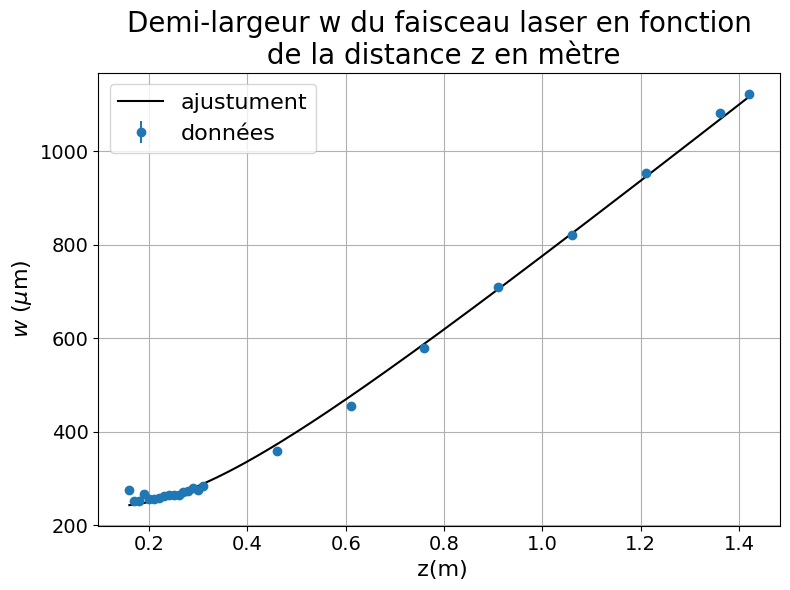

In [236]:
z = np.array(list(laDica.keys()))/100
def courbeQuad(z,w0,z0): #rappel w est en micron et z en cm
    zR = np.pi*(w0*1e-06)**2/(632.8*1e-09) #m
    
    return w0 * np.sqrt(1+ ((z-z0)/(zR))**2) #ici il fallait convertir zR dans les mêmes unités que z

w0_0 = ws.min()
z0_0 = z[ws.argmin()]
p0 = [w0_0,z0_0]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt,pcov = curve_fit(courbeQuad,z,ws,p0=p0,bounds=bounds, maxfev=200000)
w0_fit, z0_fit = popt
print(f'{w0_fit:.1f} +- {np.sqrt(pcov[0, 0]):.1f} micromètre, {z0_fit:.3f} +- {np.sqrt(pcov[1,1]):.3f} mètre') # les valeurs expérimentales de w0 et z0 en um et en m


Z = np.linspace(z.min(),z.max(),200)
plt.figure(figsize=(8,6))
plt.errorbar(z,ws,label='données',ls='',marker='o',yerr=dws)
plt.plot(Z,courbeQuad(Z,*popt),color='black',label='ajustument')
plt.ylabel(r'$w$ ($\mu$m)',fontsize=16)
plt.xlabel(r' z(m)',fontsize=16)
plt.grid(True)
plt.title('Demi-largeur w du faisceau laser en fonction\n de la distance z en mètre',fontsize=20)
plt.legend(loc='upper left',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('donnees\\graphes\\fitz0.png')


In [175]:
zRfit0 = (w0_fit*1e-06)**2*np.pi/(632.8*1e-09)
print(f'zR={zRfit0:.2f}m')

theta = np.degrees(w0_fit*1e-06 * zRfit0)*3600
dtheta = (632.8*1e-09)/np.pi/(w0_fit*1e-06)**2*(np.sqrt(pcov[0, 0])*1e-06) *3600
print(f'theta={theta:.2f}" +- {dtheta:.2f}"') #arc-secondes

zR=0.29m
theta=14.20" +- 0.02"


In [258]:
donnees1lentille = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lent1v2')

distance1lent = [float(i.replace('cm','').replace('1lent','').replace('p','.')) for i in donnees1lentille]

dic1lent_no = dict(zip(distance1lent,donnees1lentille)) #permet de trier les valeurs selon la distance
dic1lent = dict(sorted(dic1lent_no.items())) #me creer un dictionnaire qui est ordonné selon la distance
for i in dic1lent:
    print(dic1lent[i])
    spectre1lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lent1v2\\{dic1lent[i]}')
    #plt.scatter(spectre1lent[1:,0],spectre1lent[1:,1])
    #plt.show()

8cm1lent
9cm1lent
10cm1lent
11cm1lent
12cm1lent
13cm1lent
14cm1lent
15cm1lent
16cm1lent
17cm1lent
18cm1lent
19cm1lent
20cm1lent
21cm1lent
22cm1lent
23cm1lent
24cm1lent
25cm1lent
26cm1lent
27cm1lent
28cm1lent
29cm1lent
30cm1lent
35cm1lent
40cm1lent
45cm1lent
50cm1lent
60cm1lent
75cm1lent
100cm1lent


In [259]:
ws1lent = np.zeros(len(dic1lent))
for k,i in enumerate(dic1lent):
    spectre1lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lent1v2\\{dic1lent[i]}')
    x = spectre1lent[1:,0]
    y = spectre1lent[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws1lent[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    print(dic1lent[i])
    #X = np.arange(min(x),max(x))
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt),color='black')
    #plt.show()

0.8734289544735628 221.3848763025421
8cm1lent
0.7909878633268863 221.42935264090266
9cm1lent
0.5522877698067005 218.12036245380133
10cm1lent
0.5483569685568445 214.58974736006388
11cm1lent
0.7099517091819271 192.804720973481
12cm1lent
0.7386775257121839 189.38411668245516
13cm1lent
0.7461261703200676 182.81448045637484
14cm1lent
0.7751196412647986 183.8031488701546
15cm1lent
0.863238297199863 172.00940865359053
16cm1lent
0.8377545247001075 168.2170459456511
17cm1lent
0.6951290184479719 160.46685177468055
18cm1lent
0.7076484918050978 160.62950339858676
19cm1lent
0.5828936375468532 158.58748425927558
20cm1lent
0.5253333747009252 159.3142420376587
21cm1lent
0.5307417363207404 160.32135527427434
22cm1lent
0.36158863796050034 164.6089048646107
23cm1lent
0.4011682185477487 163.94000076109506
24cm1lent
0.35130467540093285 163.802375359316
25cm1lent
0.38128638830531486 176.29525857566395
26cm1lent
0.40329679794298035 175.18833307158312
27cm1lent
0.36437023318391304 176.1234185415339
28cm1lent


163.79799683593555 0.3630401803359783
0.8, 0.0017


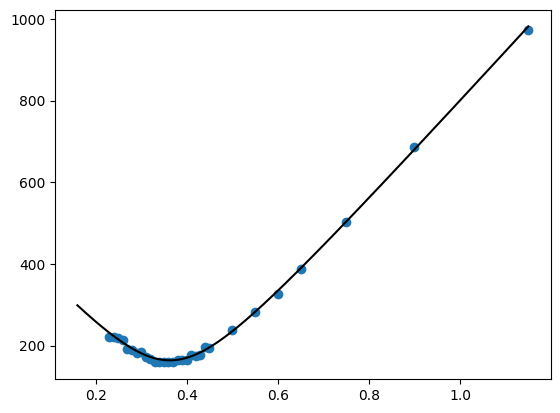

In [322]:
z_1lent = np.array(list(dic1lent.keys()))/100

w0_1 = ws1lent.min()
z0_1 = z[ws1lent.argmin()]
p01 = [w0_1,z0_1]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt1,pcov1 = curve_fit(courbeQuad,z_1lent,ws1lent,p0=p01,bounds=bounds, maxfev=200000)
w01_fit, z01_fit = popt1
print(w01_fit, z01_fit+.15)
print(f'{np.sqrt(pcov1[0, 0]):.1f}, {np.sqrt(pcov1[1,1]):.4f}')

Z = np.linspace(0.01,z_1lent.max(),200)
plt.scatter(z_1lent+.15,ws1lent)
plt.plot(Z+.15,courbeQuad(Z,*popt1),color='black')
plt.savefig('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\graphes\\fitz0_1v2.png')


In [351]:
##################################### Partie théorique pour les q' ##################################

def UnSurq_z(q,A,B,C,D):
    return  ( C+D*(1/q) ) / ( A + B*(1/q) )

q_z1 = 1j*zRfit0
unsurq2 = UnSurq_z(q_z1,1,0.03,0,1)
q_z2 = 1/unsurq2
unsurq3 = UnSurq_z(q_z2,1,0,-1/.20,1)

#####################################################################################################

In [1]:
##################################### Comparaison théorie vs expérimentale pour 1 lentille ##########

ztheo1 = np.linspace(.01,1,300)

w_z3 = np.zeros(len(ztheo1))
for k,i in enumerate(ztheo1):
    #print(k,i/100)
    Q = UnSurq_z(1/unsurq3,1,(i-.1199),0,1)
    #print(Q)
    Q=Q.imag
    w_z3[k] = np.sqrt( -(632.8e-09)/(np.pi*Q))
    #print(w_z3*1000000)
    
plt.plot(ztheo1+.15,w_z3*1000000)
plt.plot(Z+.15,courbeQuad(Z,*popt1),color='black')
plt.scatter(z_1lent+.15,ws1lent)



NameError: name 'np' is not defined

In [313]:
print(f'{ztheo1[np.argmin(w_z3)]+.15}m,{w_z3.min() * 1000000}um')

0.40832775919732445m,144.22013743451006um


In [325]:
zRfit01 = (w01_fit*1e-06)**2*np.pi/(632.8*1e-09)
print(f'zR={zRfit01:.2f}m')

theta1 = np.degrees(w01_fit*1e-06 * zRfit01)*3600
dtheta1 = (632.8*1e-09)/np.pi/(w01_fit*1e-06)**2*(np.sqrt(pcov1[0, 0])*1e-06) *3600
print(f'theta={theta1:.2f}" +- {dtheta1:.2f}"') #arc-secondes

#calcule de theta_theo
zRtheo1 = w_z3.min()**2*np.pi/(632.8*1e-09)
theta_theo1 = np.degrees(w_z3.min() * zRfit01)*3600
print(theta_theo1)

zR=0.13m
theta=4.50" +- 0.02"
3.96233885315857


2 LENTILLES


In [295]:
donnees2lentille = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille2')

distance2lent = [float(i.replace('cm','').replace('_l2','').replace('p','.')) for i in donnees2lentille]

dic2lent_no = dict(zip(distance2lent,donnees2lentille)) #permet de trier les valeurs selon la distance
dic2lent = dict(sorted(dic2lent_no.items())) #me creer un dictionnaire qui est ordonné selon la distance

ws2lent = np.zeros(len(dic2lent))
for k,i in enumerate(dic2lent):
    print(dic2lent[i])
    spectre2lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille2\\{dic2lent[i]}')
    
    #######################Si je veux voir que les graphes#################################################
    #plt.scatter(spectre2lent[1:,0],spectre2lent[1:,1])
    #plt.show()
    #######################################################################################################
    
    
    x = spectre2lent[1:,0]
    y = spectre2lent[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws2lent[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    X = np.arange(min(x),max(x))
    
    ######################## Si je veux voir les graphes avec le curve_fit ####################################
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt2),color='black')
    #plt.show()
    #########################################################################################################

20cm_l2
0.9114388364107889 306.0450540931553
25cm_l2
1.331575373770782 229.91171585551464
26cm_l2
1.2429489965278733 184.57135416689565
27cm_l2
0.895427997744526 175.4990959973287
28cm_l2
1.1988410022329168 178.55957427369552
29cm_l2
1.0016731855197498 149.54603764811674
30cm_l2
0.9600049465087327 117.78838704701185
31cm_l2
0.8973653252143504 113.23906967825582
32cm_l2
0.5867337427361841 101.20308225840594
33cm_l2
0.6182161401753108 106.17616403957064
34cm_l2
0.3608079268011804 102.60170037890835
35cm_l2
0.33105226581031294 103.21030060376278
36cm_l2
0.32952677641374606 101.87627512514908
45cm_l2
0.2936534225827115 100.63996145443248
55cm_l2
0.34973444350730787 417.9185115261328
65cm_l2
0.5479767167316929 602.2212044016464
75cm_l2
1.24156235770587 789.8118732055824
78cm_l2
2.967757129907572 741.5106066098944


107.90352701005676 1.001783815791887
3.70916163197736 0.0074767924019412


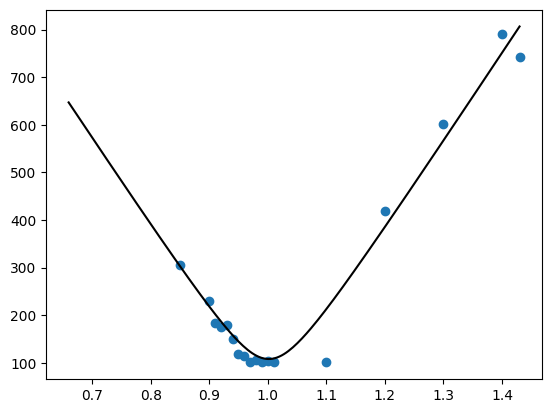

In [329]:
############################ W vs Z pour 2 lentilles convergentes ###########################################
z_2lent = np.array(list(dic2lent.keys()))/100

w0_2 = ws2lent.min()
z0_2 = z[ws2lent.argmin()]
p02 = [w0_2,z0_2]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt2,pcov2 = curve_fit(courbeQuad,z_2lent,ws2lent,p0=p02,bounds=bounds, maxfev=200000)
w02_fit, z02_fit = popt2
print(w02_fit, z02_fit+.65)
print(np.sqrt(pcov2[0,0]),np.sqrt(pcov2[1,1]))

Z2 = np.linspace(0.01,z_2lent.max(),200)
plt.scatter(z_2lent+.65,ws2lent)
plt.plot(Z2+.65,courbeQuad(Z2,*popt),color='black')
plt.savefig('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\graphes\\fitz0_2.png')
#############################################################################################################

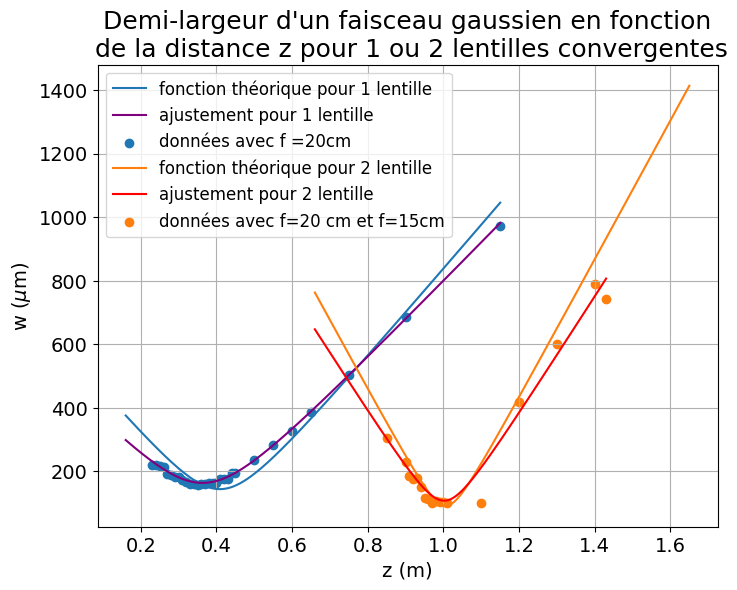

In [312]:
############################### Calcul du parcours optique depuis la 1ere lentille jusqu'à la 2ieme ###################################
q_z3 = 1/unsurq3
unsurq4 = UnSurq_z(q_z3,1,0.50,0,1)
q_z4 = 1/unsurq4
unsurq5 = UnSurq_z(q_z4,1,0,-1/.15,1)
ztheo2 = np.linspace(.01,1,300)
#######################################################################################################################################

w_z5 = np.zeros(len(ztheo2))
for k,i in enumerate(ztheo2):
    #print(k,i/100)
    Q = UnSurq_z(1/unsurq5,1,(i-.1199),0,1)
    #print(Q)
    Q=Q.imag
    w_z5[k] = np.sqrt( -(632.8e-09)/(np.pi*Q))
    #print(w_z3*1000000)
    


#plottons les 2 ensembles avec leurs fit respectifs
plt.figure(figsize=(8,6))
plt.plot(ztheo1+.15,w_z3*1000000,label='fonction théorique pour 1 lentille')
plt.plot(Z+.15,courbeQuad(Z,*popt1),color='purple',label='ajustement pour 1 lentille')
plt.scatter(z_1lent+.15,ws1lent,label='données avec f =20cm')


plt.plot(ztheo2+.65,w_z5*1000000,label='fonction théorique pour 2 lentille')
plt.plot(Z2+.65,courbeQuad(Z2,*popt),color='red',label='ajustement pour 2 lentille')
plt.scatter(z_2lent+.65,ws2lent,label='données avec f=20 cm et f=15cm')

plt.xlabel('z (m)',fontsize=14)
plt.ylabel(r'w ($\mu$m)',fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=12)
plt.grid()

plt.title('Demi-largeur d\'un faisceau gaussien en fonction\n de la distance z pour 1 ou 2 lentilles convergentes',fontsize=18)
plt.savefig('donnees\\graphes\\leslentilles.png')



In [280]:
print(f'{ztheo2[np.argmin(w_z5)]+.65}m,{w_z5.min() * 1000000}um')


1.0043478260869565m,92.05393325778775um


In [330]:
zRfit02 = (w02_fit*1e-06)**2*np.pi/(632.8*1e-09)
print(f'zR={zRfit02:.2f}m')

theta2 = np.degrees(w02_fit*1e-06 * zRfit02)*3600
dtheta2 = (632.8*1e-09)/np.pi/(w02_fit*1e-06)**2*(np.sqrt(pcov2[0, 0])*1e-06) *3600
print(f'theta={theta2:.2f}" +- {dtheta2:.2f}"') #arc-secondes

#calcule de theta_theo
zRtheo2 = w_z5.min()**2*np.pi/(632.8*1e-09)
theta_theo2 = np.degrees(w_z5.min() * zRfit02)*3600
print(theta_theo2)

zR=0.06m
theta=1.29" +- 0.23"
1.0975445718141335


Expérience supplémemtaire, prenons une lentille large et comparons avec l'approximation des lentilles minces.

In [365]:
donneesfat = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\fat2')

distancefat = [float(i.replace('cm','').replace('fat2','').replace('p','.')) for i in donneesfat]

dicfat_no = dict(zip(distancefat,donneesfat)) #permet de trier les valeurs selon la distance
dicfat = dict(sorted(dicfat_no.items())) #me creer un dictionnaire qui est ordonné selon la distance

wsfat = np.zeros(len(dicfat))
for k,i in enumerate(dicfat):
    print(dicfat[i])
    spectrefat = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\fat2\\{dicfat[i]}')
    
    #######################Si je veux voir que les graphes#################################################
    #plt.scatter(spectre2lent[1:,0],spectre2lent[1:,1])
    #plt.show()
    #######################################################################################################
    
    
    x = spectrefat[1:,0]
    y = spectrefat[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    wsfat[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    X = np.arange(min(x),max(x))
    
    ########################Si je veux voir les graphes avec le curve_fit####################################
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt),color='black')
    #plt.show()
    #########################################################################################################

8cmfat2
1.2427635150029974 171.6516408222919
8p5cmfat2
0.7058300115037017 156.94601209349193
9cmfat2
1.2924839549634946 163.45146696221843
9p5cmfat2
0.9921041254243237 158.02400049489106
10cmfat2
0.9323954678212882 157.21124049564222
10p5cmfat2
0.8732531776190443 154.68421036763036
11cmfat2
1.0900219407783802 160.33591060933517
11p5cmfat2
1.0336492548770106 157.2070547942523
12cmfat2
1.0287194356024942 156.76390104654692
12p5cmfat2
0.6276216162604696 90.64663538242431
13cmfat2
0.6950891652454868 90.70612313083626
13p5cmfat2
0.44359801163968526 78.21442206530482
14cmfat2
0.5621336818237955 78.65583916657478
14p5cmfat2
0.5604703479211286 77.77562927062542
15cmfat2
0.5575030468846789 78.44779785258329
16cmfat2
0.5630196261135925 78.34492629337629
17cmfat2
0.665591898583879 81.02655917098697
18cmfat2
0.6896321028654329 80.3915640176585
19cmfat2
0.683806387864255 80.4562893103276
20cmfat2
1.3381241352183022 186.2211936164064
25cmfat2
2.57805032210498 297.84494669678423
30cmfat2
3.5260872070

63.95357624396825 0.2989307815798984
1.8766257797316246 0.005921729588728002


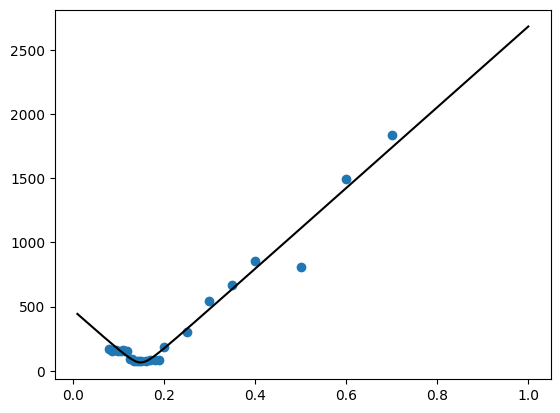

In [366]:
############################ W vs Z pour la lentille large (AVEC L'APPROXIMATION LENTILLE MINCE) #############
z_fat = np.array(list(dicfat.keys()))/100

w0_fat = wsfat.min()
z0_fat = z[wsfat.argmin()]
p0fat = [w0_fat,z0_fat]
bounds = ([0,-np.inf],[np.inf,np.inf])
poptfat,pcovfat = curve_fit(courbeQuad,z_fat,wsfat,p0=p0fat,bounds=bounds, maxfev=200000)
w0fat_fit, z0fat_fit = poptfat
print(w0fat_fit, z0fat_fit+.15)
print(np.sqrt(pcovfat[0,0]),np.sqrt(pcovfat[1,1]))

Z3 = np.linspace(0.01,z_fat.max(),200)

plt.scatter(z_fat,wsfat)
plt.plot(Z,courbeQuad(Z,*poptfat),color='black')
plt.savefig('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\graphes\\fitzFat2.png')
#############################################################################################################

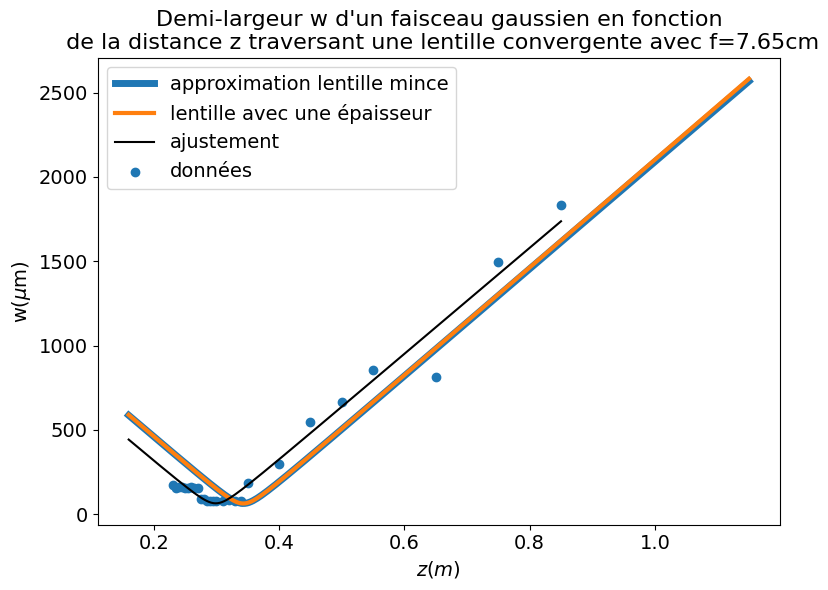

In [419]:

unsurq3fat = UnSurq_z(q_z2, 1, 0, -1 / .0765, 1)

unsurq2prime = UnSurq_z(q_z2,1,0,0,1/1.51509)
q2_exact_prime = 1/unsurq2prime
unsurq3fat_exact = UnSurq_z(q2_exact_prime,1,12.383e-03/1.51509,0,1)
q3_exact = 1/unsurq3fat_exact
unsurq4_exact = UnSurq_z(q3_exact,1,0,-(1.51509-1)/39.070e-03,1.51509/1)

#####################################################################################################
##################################### Comparaison théorie vs expérimentale pour 1 lentille ##########

ztheofat = np.linspace(.01, 1, 300)

w_z3fat = np.zeros(len(ztheofat))
w_z3fat_exact = np.zeros(len(ztheofat))
for k, i in enumerate(ztheofat):
    #print(k,i/100)
    Qfat = UnSurq_z(1/unsurq3fat, 1, (i-.1199), 0, 1)
    Qfat_exact = UnSurq_z(1/unsurq4_exact,1,(i-.1199),0,1)
    #print(Q)
    Qfat = Qfat.imag
    Qfat_exact = Qfat_exact.imag
    w_z3fat[k] = np.sqrt(-(632.8e-09) / (np.pi * Qfat))
    w_z3fat_exact[k] =  np.sqrt(-(632.8e-09) / (np.pi * Qfat_exact))
    #print(w_z3*1000000)

plt.figure(figsize=(8,6))
plt.plot(ztheofat+.15, w_z3fat * 1000000,label='approximation lentille mince',linewidth=5)
plt.plot(ztheofat + .15, w_z3fat_exact*1000000,label='lentille avec une épaisseur',linewidth=3)
plt.plot(Z3 +.15 , courbeQuad(Z3, *poptfat), color='black',label='ajustement')
plt.scatter(z_fat+.15, wsfat,label='données')
plt.xlabel(r'$z(m)$',fontsize=14)
plt.ylabel(r'w($\mu$m)',fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Demi-largeur w d\'un faisceau gaussien en fonction\n de la distance z traversant une lentille convergente avec f=7.65cm',fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()

plt.savefig('donnees\\graphes\\supplement.png')

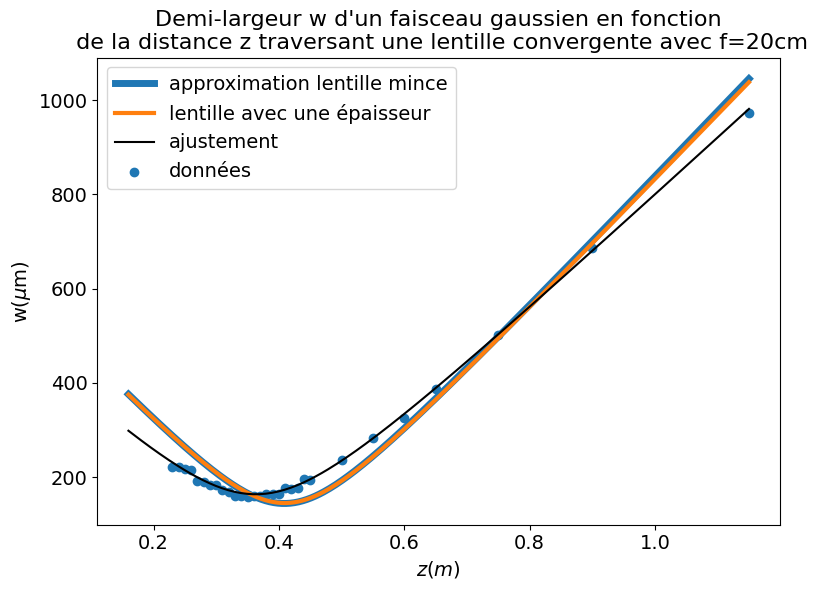

In [418]:
unsurq320 = UnSurq_z(q_z2, 1, 0, -1 / .2, 1)

unsurq2prime20 = UnSurq_z(q_z2,1,0,0,1/1.51509)
q2_exact_prime20 = 1/unsurq2prime20
unsurq3fat_exact20 = UnSurq_z(q2_exact_prime20,1,6.17e-03/1.51509,0,1)
q3_exact20 = 1/unsurq3fat_exact20
unsurq4_exact20 = UnSurq_z(q3_exact20,1,0,-(1.51509-1)/103.360e-03,1.51509/1)

#####################################################################################################
##################################### Comparaison théorie vs expérimentale pour 1 lentille ##########

ztheofat = np.linspace(.01, 1, 300)

w_z3fat = np.zeros(len(ztheofat))
w_z3fat_exact = np.zeros(len(ztheofat))
for k, i in enumerate(ztheofat):
    #print(k,i/100)
    Qfat = UnSurq_z(1/unsurq320, 1, (i-.1199), 0, 1)
    Qfat_exact = UnSurq_z(1/unsurq4_exact20,1,(i-.1199),0,1)
    #print(Q)
    Qfat = Qfat.imag
    Qfat_exact = Qfat_exact.imag
    w_z3fat[k] = np.sqrt(-(632.8e-09) / (np.pi * Qfat))
    w_z3fat_exact[k] =  np.sqrt(-(632.8e-09) / (np.pi * Qfat_exact))
    #print(w_z3*1000000)

plt.figure(figsize=(8,6))
plt.plot(ztheo1+.15, w_z3fat * 1000000,label='approximation lentille mince',linewidth=5)
plt.plot(ztheofat + .15, w_z3fat_exact*1000000,label='lentille avec une épaisseur',linewidth=3)
plt.plot(Z +.15 , courbeQuad(Z, *popt1), color='black',label='ajustement')
plt.scatter(z_1lent+.15, ws1lent,label='données')
plt.xlabel(r'$z(m)$',fontsize=14)
plt.ylabel(r'w($\mu$m)',fontsize=14)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Demi-largeur w d\'un faisceau gaussien en fonction\n de la distance z traversant une lentille convergente avec f=20cm',fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()

plt.savefig('donnees\\graphes\\supplement2.png')

In [420]:
print(f'{ztheofat[np.argmin(w_z3fat_exact)] + .15}m,{w_z3fat_exact.min() * 1000000}um')

zRfitfat = (w0fat_fit * 1e-06) ** 2 * np.pi / (632.8 * 1e-09)
print(f'zR={zRfitfat:.2f}m')

theta2 = np.degrees(w0fat_fit * 1e-06 * zRfitfat) * 3600
dtheta2 = (632.8 * 1e-09) / np.pi / (w0fat_fit * 1e-06) ** 2 * (np.sqrt(pcovfat[0, 0]) * 1e-06) * 3600
print(f'theta={theta2:.2f}" +- {dtheta2:.2f}"')  #arc-secondes

#calcule de theta_theo
zRtheofat = w_z3fat_exact.min() ** 2 * np.pi / (632.8 * 1e-09)
theta_theofat = np.degrees(w_z3fat_exact.min() * zRfitfat) * 3600
print(theta_theofat)

0.3421070234113712m,63.03571978694307um
zR=0.02m
theta=0.27" +- 0.33"
0.26401276263861734
